# 🌙 Sleep State Prediction 🛌.ipynb



# Libraries

In [ ]:
# Importing necessary libraries for the notebook
import gc  # Garbage collection for memory management
import random  # Random number generation
from itertools import groupby  # Group consecutive elements (used for event detection)

import numpy as np  # Numerical operations
import pandas as pd  # Data manipulation
import matplotlib.pyplot as plt  # Static plots
import seaborn as sns  # Statistical data visualization

# scikit-learn: data splitting and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    average_precision_score,
    confusion_matrix,
    precision_score,
)

# Gradient boosting and classification models used by the ensemble
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Show all columns in dataframe previews
pd.set_option("display.max_columns", None)

# Suppress noisy user warnings to keep the output clean
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Check Dataset

In [ ]:
# Data paths. On Kaggle these default to the mounted competition datasets;
# override DATA_DIR / TEST_PATH to run locally against your own parquet files.
import os

TRAIN_PATH = os.environ.get(
    "TRAIN_PATH",
    "/kaggle/input/zzzs-lightweight-training-dataset-target/Zzzs_train.parquet",
)
TEST_PATH = os.environ.get(
    "TEST_PATH",
    "/kaggle/input/child-mind-institute-detect-sleep-states/test_series.parquet",
)

# Reading the training and test data from Parquet files
train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)

# Parsing the timestamp and creating an "hour" feature
train["timestamp"] = pd.to_datetime(train["timestamp"], utc=True)
train["hour"] = train["timestamp"].dt.hour

test["timestamp"] = pd.to_datetime(test["timestamp"], utc=True)
test["hour"] = test["timestamp"].dt.hour

# Displaying the first few rows of the training data
train.head()

# Feature Engineering

In [ ]:
# Function to create additional features in the dataframe
def create_features(df):
    # Parsing the timestamp and creating time features
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df["hour"] = (df["timestamp"].dt.hour).astype("int8")
    df["minute"] = df["timestamp"].dt.minute

    # Half-hour period index (0-47)
    df["half_hour"] = (df["hour"] * 2 + (df["minute"] // 30)).astype("int8")
    df.drop(columns=["minute"], inplace=True)

    # Feature cross: |anglez| * enmo
    df["anglez_times_enmo"] = abs(df["anglez"]) * df["enmo"].astype("float16")

    # Rolling / difference features over `periods` steps (250 s).
    periods = 50
    df["anglez_diff"] = (
        df.groupby("series_id")["anglez"].diff(periods=periods).bfill().astype("float16")
    )
    df["enmo_diff"] = (
        df.groupby("series_id")["enmo"].diff(periods=periods).bfill().astype("float16")
    )
    df["anglez_rolling"] = (
        df["anglez"].rolling(periods, center=True).mean().bfill().ffill().astype("float16")
    )
    df["enmo_rolling"] = (
        df["enmo"].rolling(periods, center=True).mean().bfill().ffill().astype("float16")
    )
    df["anglez_diff_rolling"] = (
        df["anglez_diff"].rolling(periods, center=True).mean().bfill().ffill().astype("float16")
    )
    df["enmo_diff_rolling"] = (
        df["enmo_diff"].rolling(periods, center=True).mean().bfill().ffill().astype("float16")
    )

    return df


# Feature names used by the model
features = [
    "hour", "anglez_times_enmo", "half_hour", "anglez", "anglez_diff",
    "anglez_rolling", "anglez_diff_rolling", "enmo", "enmo_diff",
    "enmo_rolling", "enmo_diff_rolling",
]

# Apply the feature creation function to the training and test data
train = create_features(train)
test = create_features(test)

# Models

In [14]:
# 📊 Creating the training and testing datasets with selected features
X_train = train[features]  # Features for training
y_train = train["awake"].astype('int8')  # Target variable (converted to int8 for memory optimization)
X_test = test[features]  # Features for testing

# 🗑️ Deleting the original 'train' DataFrame to save memory
del train


In [15]:
X_train

,hour,anglez_times_enmo,half_hour,anglez,anglez_diff,anglez_rolling,anglez_diff_rolling,enmo,enmo_diff,enmo_rolling,enmo_diff_rolling
0,14,1.379040,28,-30.845301,3.216797,-28.937500,3.216797,0.0447,0.066895,0.070129,0.066895
1,14,1.514648,28,-34.181801,3.216797,-28.937500,3.216797,0.0443,0.066895,0.070129,0.066895
2,14,1.636580,28,-33.877102,3.216797,-28.937500,3.216797,0.0483,0.066895,0.070129,0.066895
3,14,2.330949,28,-34.282101,3.216797,-28.937500,3.216797,0.0680,0.066895,0.070129,0.066895
4,14,2.640218,28,-34.385799,3.216797,-28.937500,3.216797,0.0768,0.066895,0.070129,0.066895
...,...,...,...,...,...,...,...,...,...,...,...
13165555,20,1.561459,41,-10.064100,-1.317383,-11.882812,0.304932,0.1552,0.056488,0.104309,0.022812
13165556,20,1.139679,41,-10.006700,2.267578,-11.882812,0.304932,0.1139,0.014999,0.104309,0.022812
13165557,20,0.414450,41,-3.328600,11.773438,-11.882812,0.304932,0.1245,0.050507,0.104309,0.022812
13165558,20,0.804903,41,-5.903100,7.867188,-11.882812,0.304932,0.1363,-0.012497,0.104309,0.022812


In [ ]:
class Classifier:
    """Builds the dictionary of base models used by the ensemble."""

    def __init__(self, n_estimators=100, device="cpu", random_state=42):
        self.n_estimators = n_estimators
        self.device = device
        self.random_state = random_state

        self.models = self._define_model()
        self.models_name = list(self.models.keys())
        self.len_models = len(self.models)

    def _define_model(self):
        # XGBoost hyperparameters (kept for experimentation; not in the active
        # ensemble below).
        xgb_params = {
            "n_estimators": self.n_estimators,
            "eval_metric": "map",
            "verbosity": 0,
            "random_state": self.random_state,
            "scale_pos_weight": 2 / 3,
        }
        if self.device == "gpu":
            xgb_params["tree_method"] = "gpu_hist"
            xgb_params["predictor"] = "gpu_predictor"

        # LightGBM hyperparameters (Optuna-tuned).
        lgb_opt = {
            "num_leaves": 204,
            "learning_rate": 0.07649523437092402,
            "random_state": self.random_state,
        }

        # Active ensemble: LightGBM + Random Forest. Uncomment to add models.
        models = {
            "lgb_opt": lgb.LGBMClassifier(**lgb_opt),
            "rf": RandomForestClassifier(
                max_depth=3,
                min_samples_leaf=100,
                n_estimators=50,
                random_state=self.random_state,
            ),
            # "xgb": xgb.XGBClassifier(**xgb_params),
            # "lr": LogisticRegression(max_iter=150, random_state=self.random_state, n_jobs=-1),
        }
        return models

In [17]:
# 🧮 Configuration settings for the notebook
random_state = 42  # 🎲 Random seed for reproducibility
random_state_list = [42, 2022, 1234]  # 🎲 List of random seeds for experimenting
n_estimators = 150  # 🌳 Increase the number of estimators for more robust models
device = 'cpu'  # 💻 Device for model training (CPU or GPU)
early_stopping_rounds = 100  # 🛑 Increase early stopping rounds for patience
verbose = True  # 🗣️ Set verbosity to True for detailed training logs


In [ ]:
%%time

# Split into train / validation.
# NOTE: this is a plain random split. Because a single `series_id` spans many
# days, rows from the same subject can land in both train and validation, which
# leaks information and inflates the score. Prefer GroupKFold(groups=series_id)
# — see the markdown note below.
X_train_, X_val, y_train_, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=random_state
)

classifier = Classifier(
    n_estimators=n_estimators, device=device, random_state=random_state
)
test_predss = np.zeros((X_test.shape[0]))
oof_predss = np.zeros((X_train.shape[0]))

del X_train

score_dict = {name: [] for name in classifier.models_name}
models = classifier.models

oof_preds = []
test_preds = []

for name, model in models.items():
    model.fit(X_train_, y_train_)

    test_pred = model.predict_proba(X_test)[:, 1]
    y_val_pred = model.predict_proba(X_val)[:, 1]

    score = average_precision_score(y_val, y_val_pred)
    score_dict[name].append(score)
    print(f"{name} [SEED-{random_state}] Average precision: {score:.5f}")

    oof_preds.append(y_val_pred)
    test_preds.append(test_pred)

# Ensemble = mean of base-model probabilities.
test_predss = np.average(np.array(test_preds), axis=0)
oof_predss[X_val.index] = np.average(np.array(oof_preds), axis=0)

gc.collect()
del X_train_, X_val, y_val, y_train_

### Notes & recommended improvements

This notebook is **exploratory** and is *not* the model the app serves. A few
things to be aware of and to improve when re-training:

1. **Validation should be grouped by `series_id`.** A plain
   `train_test_split` leaks data because one subject's days appear in both
   folds. Use:
   ```python
   from sklearn.model_selection import GroupKFold
   gkf = GroupKFold(n_splits=5)
   for tr, va in gkf.split(X_train, y_train, groups=train["series_id"]):
       ...
   ```
2. **Metric.** `average_precision_score` here is a point-wise proxy. The Kaggle
   competition is scored with **event-detection mean Average Precision** over
   tolerance windows around each true onset/wakeup; evaluate with that to track
   leaderboard performance.
3. **Train/serve parity.** The deployed app (`app.py` / `utils.py`) uses a
   *different* feature set (`feature_engineering`, 13 features) and a *different*
   model (the XGBoost pipeline in `pipeline_01.pkl`) than this notebook's
   LightGBM + Random Forest ensemble (11 features). To make training reproduce
   what the app serves, import and reuse `utils.feature_engineering` here and
   persist the fitted pipeline (next cell).


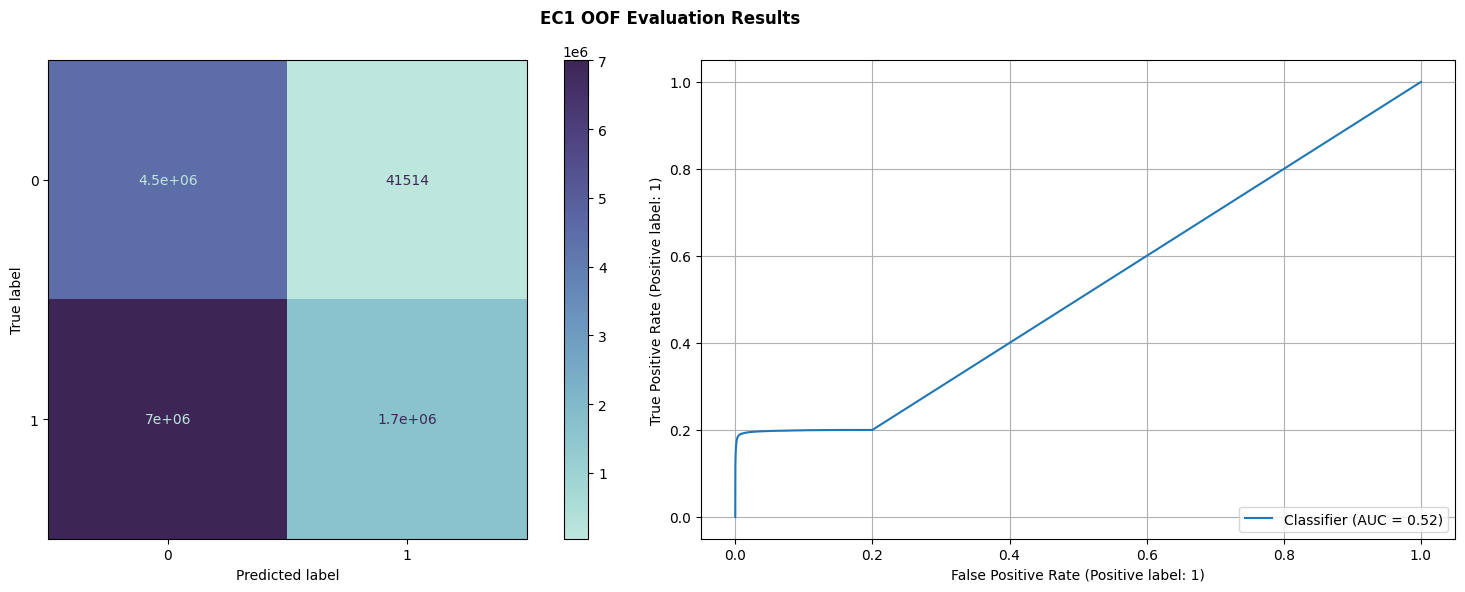

In [19]:
# 🌈 Creating a custom color palette using Seaborn
my_palette = sns.cubehelix_palette(n_colors=7, start=.46, rot=-.45, dark=.2, hue=0.95, as_cmap=True)

# 📊 Function to display the confusion matrix and ROC curve
def show_confusion_roc(oof, title='Model Evaluation Results'):
    # Creating a 1x2 subplot grid with specified figure size
    f, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # Creating a DataFrame for predictions and true labels
    df = pd.DataFrame({'preds': oof[0], 'target': oof[1]})
    
    # Calculating and plotting the confusion matrix
    cm = confusion_matrix(df.target, df.preds.ge(0.5).astype(int))
    cm_display = ConfusionMatrixDisplay(cm).plot(cmap=my_palette, ax=ax[0])
    ax[0].grid(False)
    
    # Plotting the ROC curve
    RocCurveDisplay.from_predictions(df.target, df.preds, ax=ax[1])
    ax[1].grid(True)
    
    # Adding a title to the overall plot
    plt.suptitle(f'{title}', fontsize=12, fontweight='bold')
    
    # Ensuring tight layout for better visualization
    plt.tight_layout()

# Calling the function to display evaluation results
show_confusion_roc(oof=[oof_predss, y_train], title='EC1 OOF Evaluation Results')


# Make Submission

In [ ]:
# "not_awake" is the complement of the predicted P(awake)
test["score"] = test_predss
test["not_awake"] = 1 - test["score"]

# Smooth the probability over a rolling window, then re-binarise.
smoothing_length = 500  # ~2500 s
test["smooth"] = (
    test["not_awake"].rolling(smoothing_length, center=True).mean().bfill().ffill()
)
test["smooth"] = test["smooth"].round()


def get_event(df):
    """Mark the first row of each sleep block as 'onset' and the last as 'wakeup'."""
    lstCV = zip(df.series_id, df.smooth)
    lstPOI = []
    for (c, v), g in groupby(
        lstCV, lambda cv: (cv[0], cv[1] != 0 and not pd.isnull(cv[1]))
    ):
        llg = sum(1 for _ in g)
        if v is False:
            lstPOI.extend([0] * llg)
        else:
            lstPOI.extend(
                ["onset"] + (llg - 2) * [0] + ["wakeup"] if llg > 1 else [0]
            )
    return lstPOI


# Derive the discrete onset/wakeup events
test["event"] = get_event(test)

In [21]:
# Filtering the "test" DataFrame to select rows where "event" is not equal to 0
sample_submission = test.loc[test["event"] != 0]

# Selecting specific columns and creating a copy of the DataFrame
sample_submission = sample_submission[["series_id", "step", "event", "score"]].copy()

# Resetting the index and renaming the index column to "row_id"
sample_submission = sample_submission.reset_index(drop=True).reset_index(names="row_id")

# Saving the sample submission DataFrame to a CSV file named 'submission.csv'
sample_submission.to_csv('submission.csv', index=False)


In [ ]:
# Persist the trained ensemble for the Streamlit app.
#
# The bundled pipeline_01.pkl is an XGBoost scikit-learn Pipeline; this notebook
# trains a LightGBM + Random Forest ensemble. To make the served model
# reproducible, wrap the fitted estimator(s) in the same preprocessing used at
# inference time and pickle it together with version metadata.
import pickle
import sklearn
import xgboost

artifact = {
    "models": models,            # dict of fitted base models
    "features": features,        # feature order expected at inference
    "sklearn_version": sklearn.__version__,
    "xgboost_version": xgboost.__version__,
}

with open("pipeline_01.pkl", "wb") as f:
    pickle.dump(artifact, f)

print("Saved pipeline_01.pkl", {k: artifact[k] for k in ("sklearn_version", "xgboost_version")})
